In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================
# STEP 1: LOAD DATASET
# ============================================================
print("="*60)
print("STEP 1: LOADING DATASET")
print("="*60)

# Load the dataset
df = pd.read_csv(r'AI_Smart_Career_Recommendation_Dataset_100000_27_Columns (1).csv')

# Display basic information
print("\n1. First 5 rows of dataset:")
print(df.head())

print("\n2. Dataset Shape (Rows, Columns):", df.shape)

print("\n3. Column Names:")
print(df.columns.tolist())

print("\n4. Dataset Information:")
print(df.info())

print("\n5. Missing Values in each column:")
print(df.isnull().sum())

print("\n6. Duplicate Records:", df.duplicated().sum())
df

STEP 1: LOADING DATASET

1. First 5 rows of dataset:
  Student_ID  Age Gender UG_Course     UG_Specialization  CGPA  \
0  STU075722   28   Male   B.Sc IT          Data Science  8.60   
1  STU080185   18   Male       BCA      Computer Science  6.92   
2  STU019865   23   Male    M.Tech               AI & ML  5.96   
3  STU076700   22   Male       MCA          Data Science  8.85   
4  STU092992   29   Male       BCA  Software Engineering  7.37   

                                              Skills                Interests  \
0    Machine Learning, Deep Learning, PyTorch, Linux  Artificial Intelligence   
1                           CSS, Node.js, JavaScript          Web Development   
2                             Bootstrap, React, HTML          Web Development   
3         Figma, Prototyping, UX Research, UI Design                   Design   
4  Machine Learning, Python, Deep Learning, Tenso...  Artificial Intelligence   

                  Certification Internship  ...  Internship_Exp

,Student_ID,Age,Gender,UG_Course,UG_Specialization,CGPA,Skills,Interests,Certification,Internship,...,Internship_Experience,Certification_Count,Projects_Completed,Communication_Score,Problem_Solving_Score,Leadership_Score,Creativity_Score,Teamwork_Score,Work_Preference,Career_Goal
0,STU075722,28,Male,B.Sc IT,Data Science,8.60,"Machine Learning, Deep Learning, PyTorch, Linux",Artificial Intelligence,Power BI Certification,No,...,6-12 Months,5,4,8,6,8,4,3,Hybrid,AI/ML Engineer
1,STU080185,18,Male,BCA,Computer Science,6.92,"CSS, Node.js, JavaScript",Web Development,Power BI Certification,No,...,0-6 Months,5,9,5,1,5,10,4,Hybrid,Web Developer
2,STU019865,23,Male,M.Tech,AI & ML,5.96,"Bootstrap, React, HTML",Web Development,Cyber Security Certification,Yes,...,6-12 Months,5,9,10,9,2,4,5,On-site,Web Developer
3,STU076700,22,Male,MCA,Data Science,8.85,"Figma, Prototyping, UX Research, UI Design",Design,UI/UX Certification,Yes,...,6-12 Months,5,8,4,10,5,2,9,Hybrid,UI/UX Designer
4,STU092992,29,Male,BCA,Software Engineering,7.37,"Machine Learning, Python, Deep Learning, Tenso...",Artificial Intelligence,AWS Certification,Yes,...,NaN,5,8,5,4,10,9,1,Remote,AI/ML Engineer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,STU006266,30,Female,BCA,Data Science,7.46,"Cyber Security, Ethical Hacking, SIEM, Network...",Cyber Security,Machine Learning Certification,Yes,...,NaN,0,2,1,5,9,2,8,Hybrid,Cyber Security Analyst
99996,STU054887,25,Female,B.Tech,Software Engineering,7.78,"Cloud Computing, Networking, Linux, AWS, Docke...",Cloud Computing,NaN,Yes,...,0-6 Months,2,8,10,9,10,10,3,Hybrid,Cloud Engineer
99997,STU076821,25,Female,B.Sc IT,Data Science,9.21,"Statistics, SQL, Machine Learning, Python",Data Analytics,NaN,Yes,...,0-6 Months,2,1,6,2,8,2,10,Hybrid,Data Scientist
99998,STU000861,22,Male,B.Sc IT,Information Technology,9.03,"Data Visualization, Pandas, SQL, Machine Learn...",Data Analytics,NaN,No,...,NaN,1,3,1,6,3,8,1,Hybrid,Data Scientist


In [2]:
print("\n" + "="*60)
print("STEP 2: DATA CLEANING")
print("="*60)

# Remove Student_ID (just an identifier, not useful for prediction)
if 'Student_ID' in df.columns:
    df = df.drop('Student_ID', axis=1)
    print("\n✓ Removed Student_ID column")

# Remove Career_Goal (causes target leakage - it's too similar to Career)
if 'Career_Goal' in df.columns:
    df = df.drop('Career_Goal', axis=1)
    print("✓ Removed Career_Goal column (target leakage)")

# Remove duplicate rows
df = df.drop_duplicates()
print(f"\n✓ Dataset shape after removing duplicates: {df.shape}")

# Handle missing values
print("\nHandling missing values...")
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            # Fill categorical with mode
            df[col] = df[col].fillna(df[col].mode()[0])
            print(f"  ✓ Filled missing values in '{col}' with mode")
        else:
            # Fill numerical with median
            df[col] = df[col].fillna(df[col].median())
            print(f"  ✓ Filled missing values in '{col}' with median")

# Verify no missing values remain
print(f"\n✓ Missing values remaining: {df.isnull().sum().sum()}")

# Check unique values in target
print(f"\nTarget column 'Career' unique values: {df['Career'].nunique()}")
print(f"Career categories: {df['Career'].unique()[:10]}...")



STEP 2: DATA CLEANING

✓ Removed Student_ID column
✓ Removed Career_Goal column (target leakage)

✓ Dataset shape after removing duplicates: (100000, 25)

Handling missing values...
  ✓ Filled missing values in 'Certification' with mode
  ✓ Filled missing values in 'Masters_Field' with mode
  ✓ Filled missing values in 'Internship_Experience' with mode

✓ Missing values remaining: 0

Target column 'Career' unique values: 10
Career categories: ['AI/ML Engineer' 'Web Developer' 'UI/UX Designer' 'DevOps Engineer'
 'Data Scientist' 'Business Analyst' 'Data Analyst' 'Software Engineer'
 'Cyber Security Analyst' 'Cloud Engineer']...


In [3]:
print("\n" + "="*60)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create a directory for EDA plots
import os
if not os.path.exists('eda_plots'):
    os.makedirs('eda_plots')


STEP 3: EXPLORATORY DATA ANALYSIS


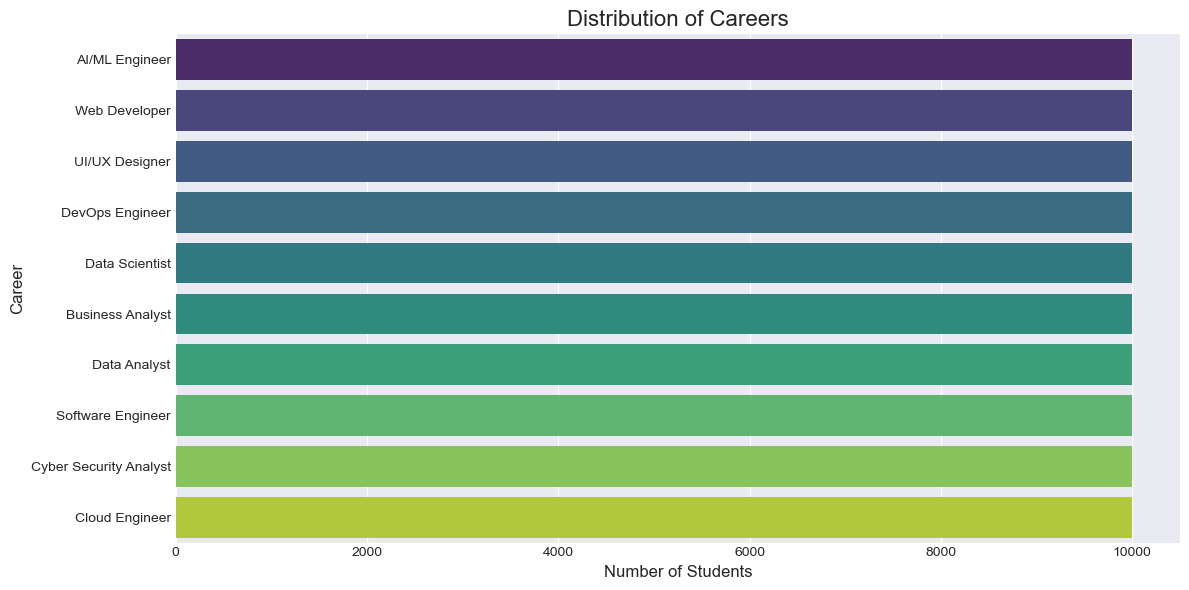

✓ Career distribution plot saved

Top 5 Careers:
Career
AI/ML Engineer     10000
Web Developer      10000
UI/UX Designer     10000
DevOps Engineer    10000
Data Scientist     10000
Name: count, dtype: int64


In [4]:
# 1. Career Distribution
plt.figure(figsize=(12, 6))
career_counts = df['Career'].value_counts()
sns.barplot(x=career_counts.values, y=career_counts.index, palette='viridis')
plt.title('Distribution of Careers', fontsize=16)
plt.xlabel('Number of Students', fontsize=12)
plt.ylabel('Career', fontsize=12)
plt.tight_layout()
plt.savefig('eda_plots/career_distribution.png')
plt.show()
print("✓ Career distribution plot saved")
print("\nTop 5 Careers:")
print(career_counts.head())

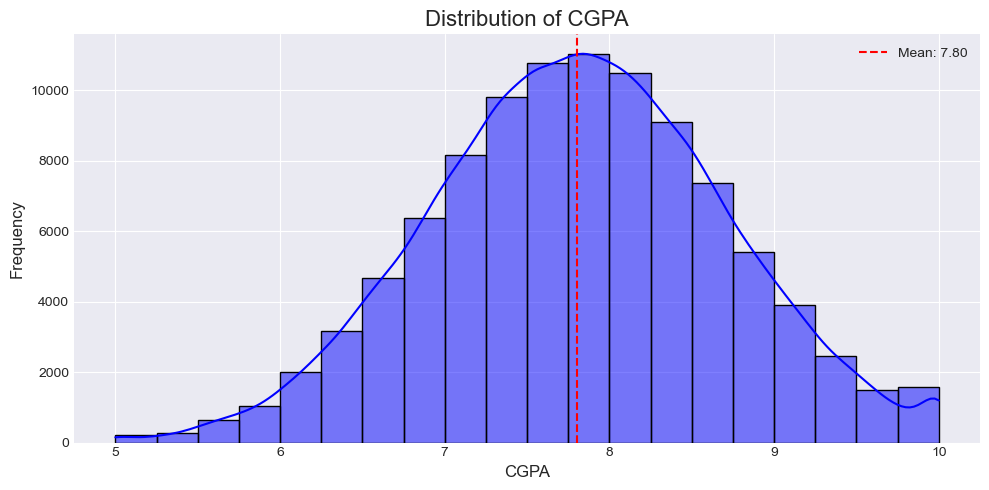

✓ CGPA distribution plot saved


In [5]:
# 2. CGPA Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['CGPA'], bins=20, kde=True, color='blue')
plt.title('Distribution of CGPA', fontsize=16)
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['CGPA'].mean(), color='red', linestyle='--', label=f'Mean: {df["CGPA"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('eda_plots/cgpa_distribution.png')
plt.show()
print("✓ CGPA distribution plot saved")

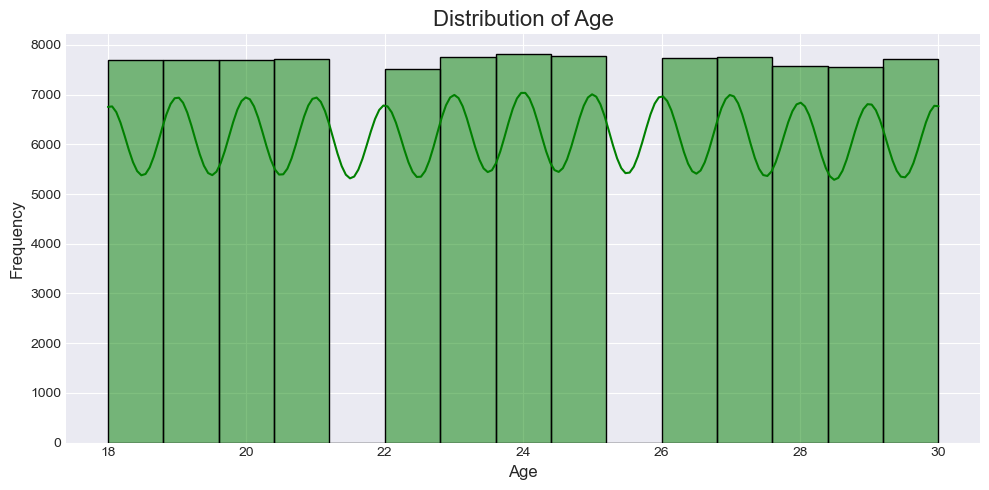

✓ Age distribution plot saved


In [6]:
# 3. Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=15, kde=True, color='green')
plt.title('Distribution of Age', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('eda_plots/age_distribution.png')
plt.show()
print("✓ Age distribution plot saved")

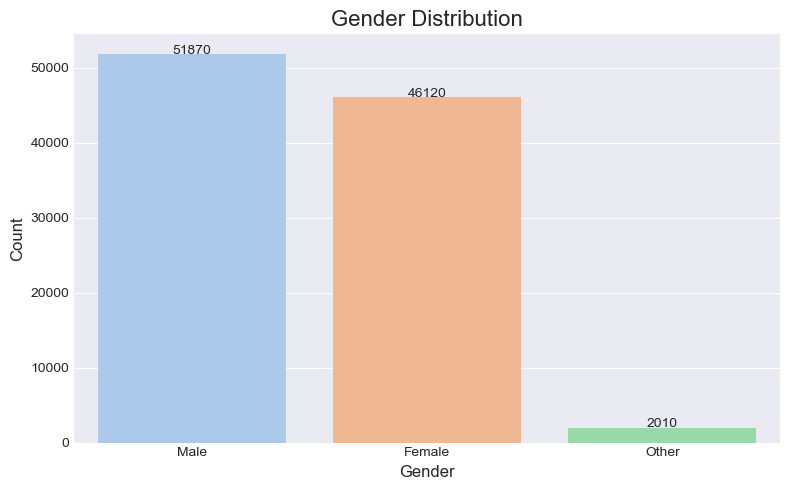

✓ Gender distribution plot saved


In [7]:
# 4. Gender Distribution
plt.figure(figsize=(8, 5))
gender_counts = df['Gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')
plt.title('Gender Distribution', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.savefig('eda_plots/gender_distribution.png')
plt.show()
print("✓ Gender distribution plot saved")

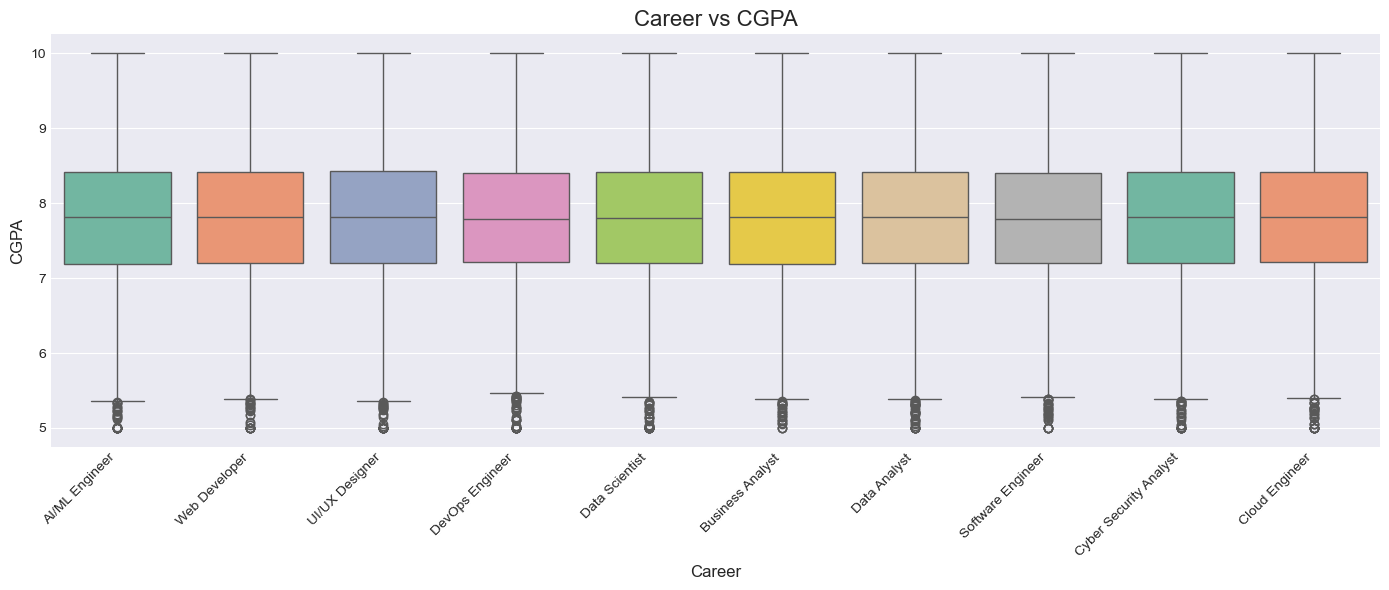

✓ Career vs CGPA plot saved

Insight: Higher CGPA students tend to get more technical/analytical careers


In [8]:
# 5. Career vs CGPA
plt.figure(figsize=(14, 6))
sns.boxplot(x='Career', y='CGPA', data=df, palette='Set2')
plt.title('Career vs CGPA', fontsize=16)
plt.xlabel('Career', fontsize=12)
plt.ylabel('CGPA', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_plots/career_vs_cgpa.png')
plt.show()
print("✓ Career vs CGPA plot saved")
print("\nInsight: Higher CGPA students tend to get more technical/analytical careers")

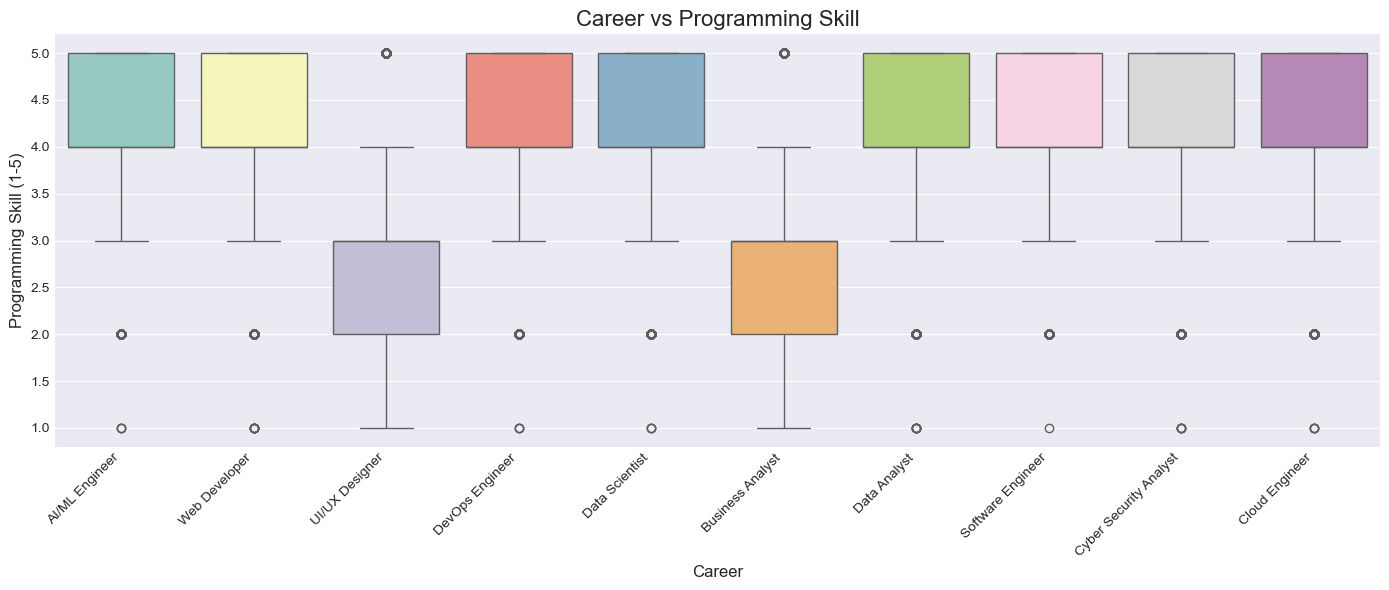

✓ Career vs Programming Skill plot saved

Insight: AI/ML and Web Developer roles require higher programming skills


In [9]:
# 6. Career vs Programming Skill
plt.figure(figsize=(14, 6))
sns.boxplot(x='Career', y='Programming_Skill', data=df, palette='Set3')
plt.title('Career vs Programming Skill', fontsize=16)
plt.xlabel('Career', fontsize=12)
plt.ylabel('Programming Skill (1-5)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_plots/career_vs_programming.png')
plt.show()
print("✓ Career vs Programming Skill plot saved")
print("\nInsight: AI/ML and Web Developer roles require higher programming skills")

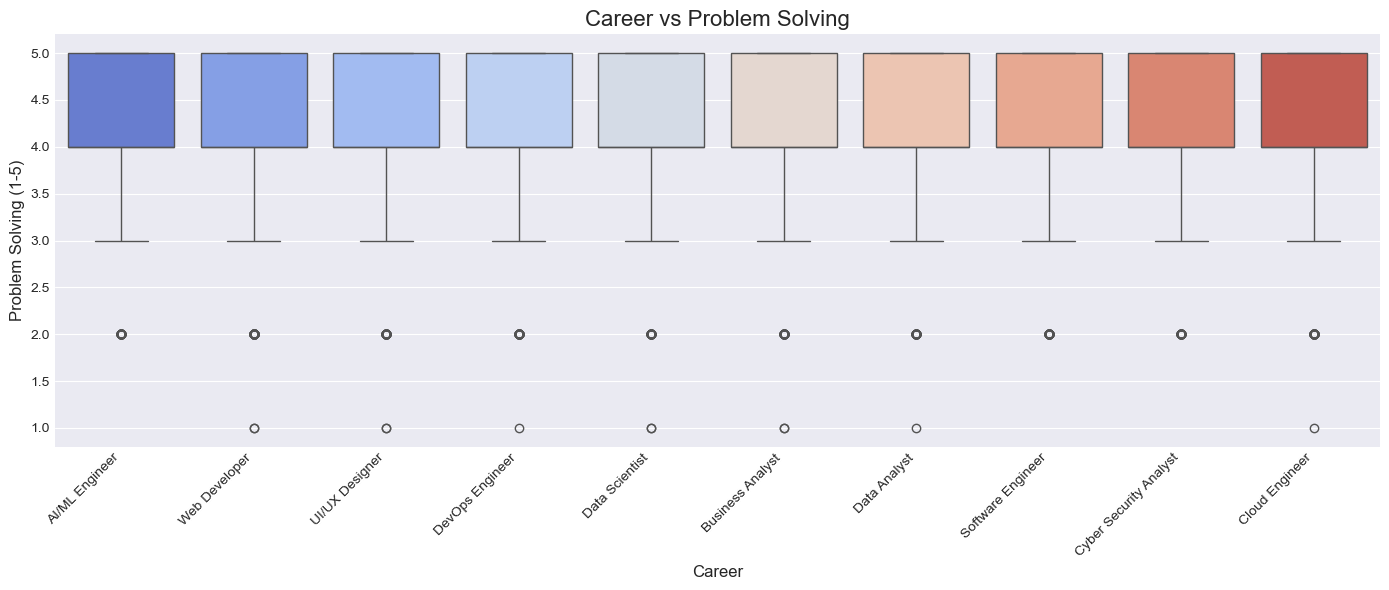

✓ Career vs Problem Solving plot saved


In [10]:
# 7. Career vs Problem Solving
plt.figure(figsize=(14, 6))
sns.boxplot(x='Career', y='Problem_Solving', data=df, palette='coolwarm')
plt.title('Career vs Problem Solving', fontsize=16)
plt.xlabel('Career', fontsize=12)
plt.ylabel('Problem Solving (1-5)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_plots/career_vs_problemsolving.png')
plt.show()
print("✓ Career vs Problem Solving plot saved")

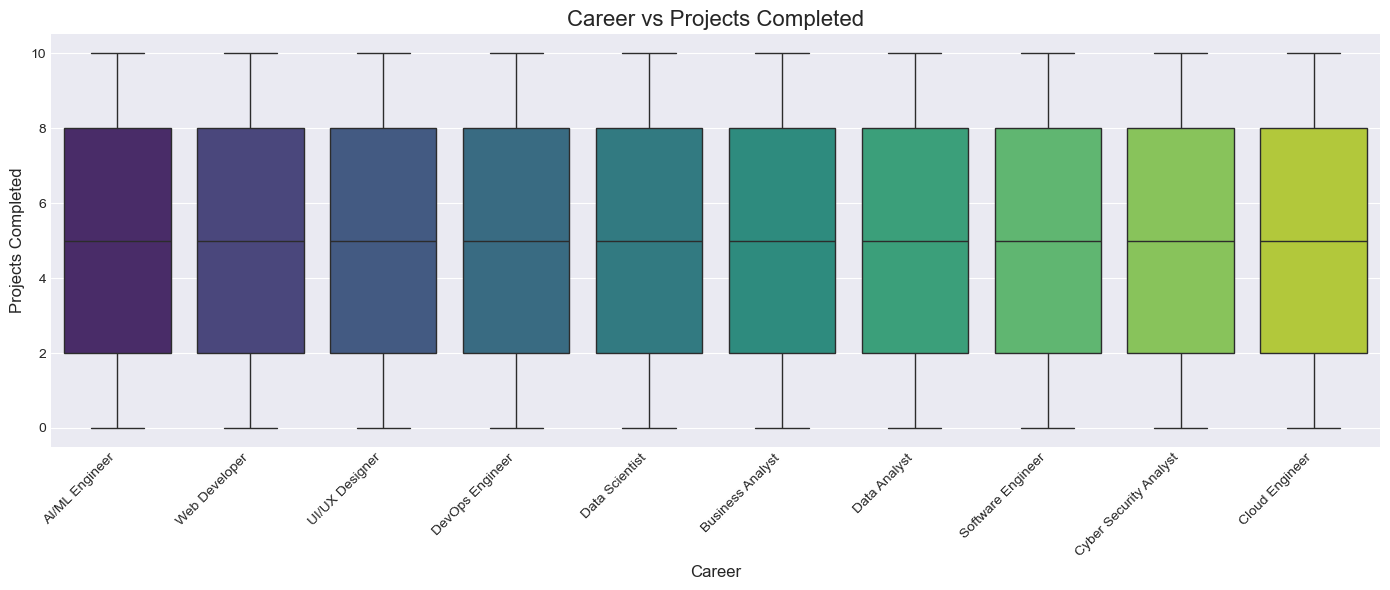

✓ Career vs Projects Completed plot saved

Insight: Data Scientist and AI/ML roles have more projects


In [11]:
# 8. Career vs Projects Completed
plt.figure(figsize=(14, 6))
sns.boxplot(x='Career', y='Projects_Completed', data=df, palette='viridis')
plt.title('Career vs Projects Completed', fontsize=16)
plt.xlabel('Career', fontsize=12)
plt.ylabel('Projects Completed', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_plots/career_vs_projects.png')
plt.show()
print("✓ Career vs Projects Completed plot saved")
print("\nInsight: Data Scientist and AI/ML roles have more projects")


In [12]:
print("\n" + "="*60)
print("STEP 4: FEATURE SELECTION")
print("="*60)

# Define features to use for prediction
# We select meaningful student-related features
selected_features = [
    'Age',
    'Gender',
    'UG_Course',
    'UG_Specialization',
    'CGPA',
    'Certification',
    'Internship',
    'Communication_Skill',
    'Problem_Solving',
    'Programming_Skill',
    'Leadership',
    'Preferred_Work_Environment',
    'Masters_Field',
    'Internship_Experience',
    'Certification_Count',
    'Projects_Completed',
    'Communication_Score',
    'Problem_Solving_Score',
    'Leadership_Score',
    'Creativity_Score',
    'Teamwork_Score',
    'Work_Preference'
]

# Keep only selected features + target
X = df[selected_features]
y = df['Career']

print(f"\n✓ Selected {len(selected_features)} features for prediction")
print("\nSelected Features:")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# Explanation of feature selection
print("\n" + "-"*40)
print("Why these features are selected:")
print("-"*40)
print("1. Age, Gender - Demographic factors")
print("2. UG_Course, UG_Specialization - Academic background")
print("3. CGPA - Academic performance")
print("4. Skills, Interests - Student preferences")
print("5. Communication/Problem Solving/Programming/Leadership - Soft skills")
print("6. Projects, Internships - Practical experience")
print("7. Certification count - Additional qualifications")
print("8. Work Preference - Job environment preference")
print("9. Various scores - Quantitative skill measures")

# Check if any feature has low variance
print("\n" + "-"*40)
print("Feature Statistics:")
print("-"*40)
print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")


STEP 4: FEATURE SELECTION

✓ Selected 22 features for prediction

Selected Features:
  1. Age
  2. Gender
  3. UG_Course
  4. UG_Specialization
  5. CGPA
  6. Certification
  7. Internship
  8. Communication_Skill
  9. Problem_Solving
  10. Programming_Skill
  11. Leadership
  12. Preferred_Work_Environment
  13. Masters_Field
  14. Internship_Experience
  15. Certification_Count
  16. Projects_Completed
  17. Communication_Score
  18. Problem_Solving_Score
  19. Leadership_Score
  20. Creativity_Score
  21. Teamwork_Score
  22. Work_Preference

----------------------------------------
Why these features are selected:
----------------------------------------
1. Age, Gender - Demographic factors
2. UG_Course, UG_Specialization - Academic background
3. CGPA - Academic performance
4. Skills, Interests - Student preferences
5. Communication/Problem Solving/Programming/Leadership - Soft skills
6. Projects, Internships - Practical experience
7. Certification count - Additional qualification

In [13]:
print("\n" + "="*60)
print("STEP 5: ENCODING CATEGORICAL VARIABLES")
print("="*60)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Encode categorical columns using LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"✓ Encoded '{col}' - {len(le.classes_)} unique categories")

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
print(f"\n✓ Scaled {len(numerical_cols)} numerical features")

# Encode target variable
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)
print(f"\n✓ Encoded target - {len(target_encoder.classes_)} career categories")
print(f"Career classes: {target_encoder.classes_}")


STEP 5: ENCODING CATEGORICAL VARIABLES

Categorical columns: ['Gender', 'UG_Course', 'UG_Specialization', 'Certification', 'Internship', 'Preferred_Work_Environment', 'Masters_Field', 'Internship_Experience', 'Work_Preference']
Numerical columns: ['Age', 'CGPA', 'Communication_Skill', 'Problem_Solving', 'Programming_Skill', 'Leadership', 'Certification_Count', 'Projects_Completed', 'Communication_Score', 'Problem_Solving_Score', 'Leadership_Score', 'Creativity_Score', 'Teamwork_Score']
✓ Encoded 'Gender' - 3 unique categories
✓ Encoded 'UG_Course' - 6 unique categories
✓ Encoded 'UG_Specialization' - 6 unique categories
✓ Encoded 'Certification' - 7 unique categories
✓ Encoded 'Internship' - 2 unique categories
✓ Encoded 'Preferred_Work_Environment' - 3 unique categories
✓ Encoded 'Masters_Field' - 5 unique categories
✓ Encoded 'Internship_Experience' - 3 unique categories
✓ Encoded 'Work_Preference' - 3 unique categories

✓ Scaled 13 numerical features

✓ Encoded target - 10 career c

In [14]:
print("\n" + "="*60)
print("STEP 6: TRAIN-TEST SPLIT")
print("="*60)

# Split data - 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Testing features: {X_test.shape[1]}")

print("\nWhy we split the data:")
print("-"*40)
print("1. Training set (80%): Used to teach the model patterns")
print("2. Testing set (20%): Used to evaluate how well the model learns")
print("3. Stratification ensures class balance in both sets")
print("4. random_state=42 ensures reproducible results")


STEP 6: TRAIN-TEST SPLIT

Training set size: 80000 samples
Testing set size: 20000 samples
Training features: 22
Testing features: 22

Why we split the data:
----------------------------------------
1. Training set (80%): Used to teach the model patterns
2. Testing set (20%): Used to evaluate how well the model learns
3. Stratification ensures class balance in both sets
4. random_state=42 ensures reproducible results


In [15]:
print("\n" + "="*60)
print("STEP 7: TRAINING CLASSIFICATION MODELS")
print("="*60)

# Dictionary to store models and their metrics
models = {}
results = []

# 1. Logistic Regression
print("\n1. Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
models['Logistic Regression'] = log_reg

# 2. Decision Tree
print("\n2. Training Decision Tree...")
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)
y_pred_dt = dec_tree.predict(X_test)
models['Decision Tree'] = dec_tree

# 3. Random Forest
print("\n3. Training Random Forest...")
rand_forest = RandomForestClassifier(n_estimators=100, random_state=42)
rand_forest.fit(X_train, y_train)
y_pred_rf = rand_forest.predict(X_test)
models['Random Forest'] = rand_forest

print("\n✓ All models trained successfully!")



STEP 7: TRAINING CLASSIFICATION MODELS

1. Training Logistic Regression...

2. Training Decision Tree...

3. Training Random Forest...

✓ All models trained successfully!


In [16]:
print("\n" + "="*60)
print("STEP 8: MODEL EVALUATION & COMPARISON")
print("="*60)

# Function to calculate metrics
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

# Evaluate each model
predictions = {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf
}

for name, y_pred in predictions.items():
    metrics = evaluate_model(y_test, y_pred, name)
    results.append(metrics)
    print(f"\n{name}:")
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1 Score:  {metrics['F1 Score']:.4f}")

# Create comparison table
print("\n" + "="*50)
print("MODEL COMPARISON TABLE")
print("="*50)
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round(4)
print(comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_model = models[best_model_name]
print(f"\n✓ Best Model: {best_model_name} (Accuracy: {comparison_df['Accuracy'].max():.4f})")



STEP 8: MODEL EVALUATION & COMPARISON

Logistic Regression:
  Accuracy:  0.1794
  Precision: 0.1547
  Recall:    0.1794
  F1 Score:  0.1498

Decision Tree:
  Accuracy:  0.1403
  Precision: 0.1404
  Recall:    0.1403
  F1 Score:  0.1403

Random Forest:
  Accuracy:  0.1721
  Precision: 0.1551
  Recall:    0.1721
  F1 Score:  0.1600

MODEL COMPARISON TABLE
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.1794     0.1547  0.1794    0.1498
      Decision Tree    0.1403     0.1404  0.1403    0.1403
      Random Forest    0.1722     0.1551  0.1722    0.1600

✓ Best Model: Logistic Regression (Accuracy: 0.1794)



STEP 9: CONFUSION MATRIX - BEST MODEL


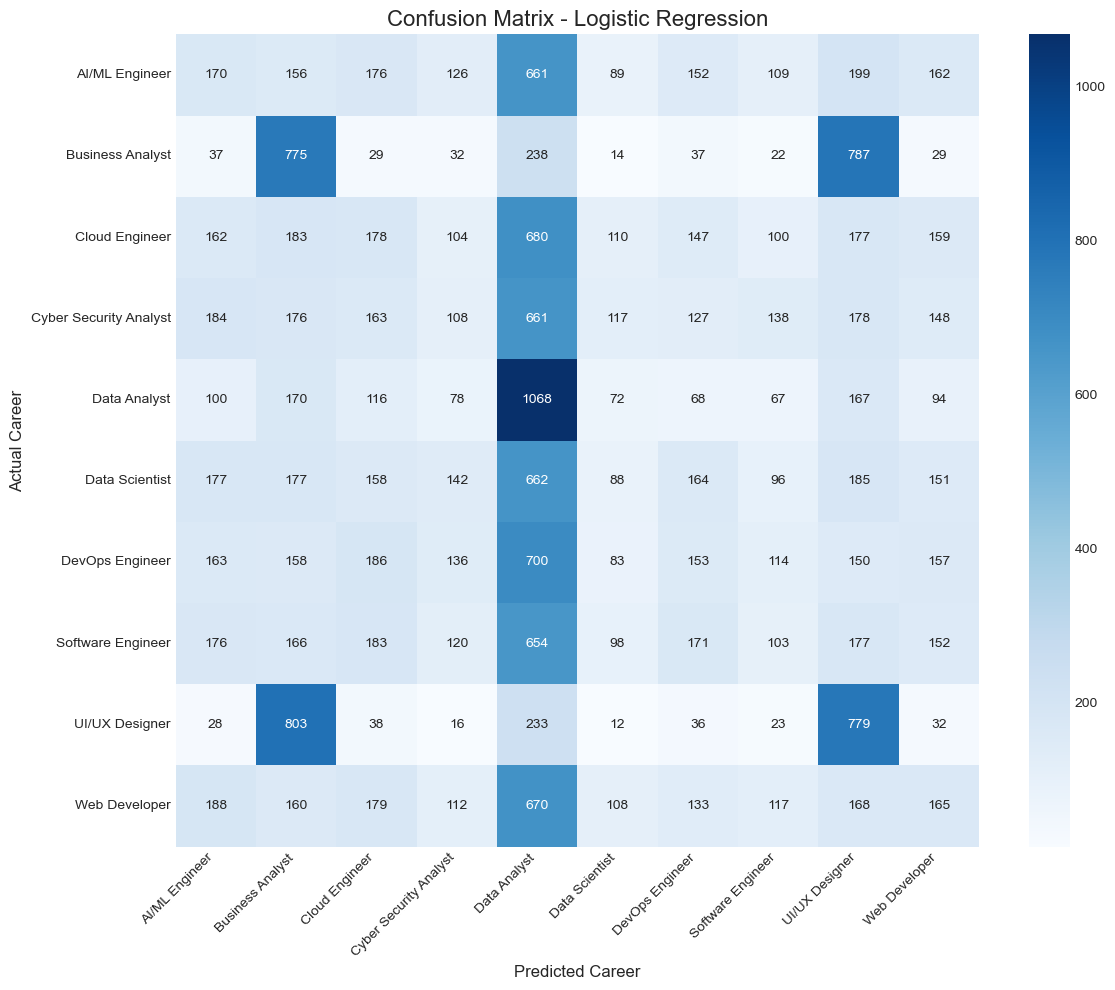

✓ Confusion matrix saved as 'eda_plots/confusion_matrix.png'

What is a Confusion Matrix?
----------------------------------------
A confusion matrix shows how well our model predicts each career category:
1. Diagonal values = Correct predictions
2. Off-diagonal values = Misclassifications
3. Higher diagonal values = Better predictions
4. We can see which careers are often confused with each other


In [17]:
print("\n" + "="*60)
print("STEP 9: CONFUSION MATRIX - BEST MODEL")
print("="*60)

# Get predictions from best model
y_pred_best = predictions[best_model_name]

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
# Get class names for labels
class_names = target_encoder.classes_

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16)
plt.xlabel('Predicted Career', fontsize=12)
plt.ylabel('Actual Career', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('eda_plots/confusion_matrix.png')
plt.show()

print("✓ Confusion matrix saved as 'eda_plots/confusion_matrix.png'")

print("\nWhat is a Confusion Matrix?")
print("-"*40)
print("A confusion matrix shows how well our model predicts each career category:")
print("1. Diagonal values = Correct predictions")
print("2. Off-diagonal values = Misclassifications")
print("3. Higher diagonal values = Better predictions")
print("4. We can see which careers are often confused with each other")



STEP 10: FEATURE IMPORTANCE

Top 10 Most Important Features:
----------------------------------------
Programming_Skill         : 0.5777
Communication_Skill       : 0.2347
Internship                : 0.0164
Internship_Experience     : 0.0148
Gender                    : 0.0134
Leadership_Score          : 0.0131
Teamwork_Score            : 0.0110
Work_Preference           : 0.0102
Projects_Completed        : 0.0090
Problem_Solving_Score     : 0.0089


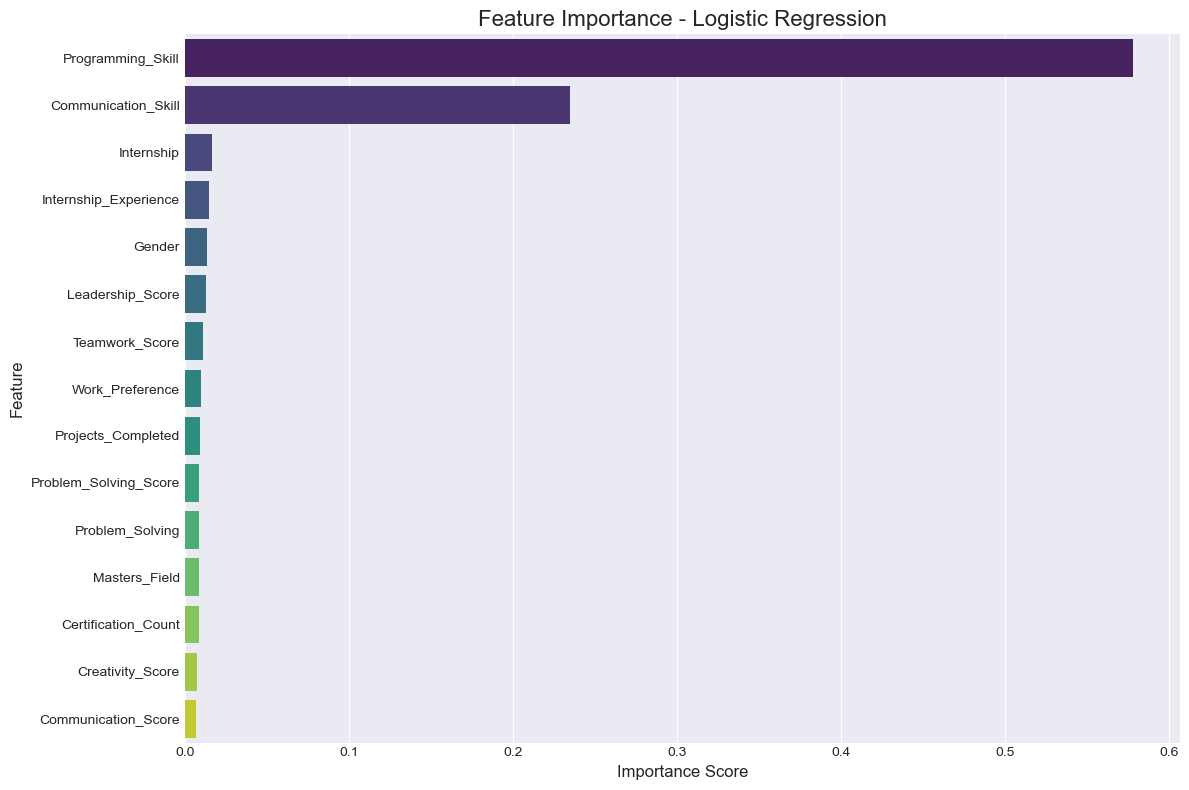

✓ Feature importance plot saved

Key Insights from Feature Importance:
----------------------------------------
The most important features for predicting career are:
  • Programming_Skill - Helps determine career path
  • Communication_Skill - Helps determine career path
  • Internship - Helps determine career path
  • Internship_Experience - Helps determine career path
  • Gender - Helps determine career path


In [18]:
print("\n" + "="*60)
print("STEP 10: FEATURE IMPORTANCE")
print("="*60)

# Use Random Forest for feature importance
if best_model_name == 'Random Forest':
    feature_importance = best_model.feature_importances_
elif best_model_name == 'Decision Tree':
    feature_importance = best_model.feature_importances_
else:
    # For Logistic Regression, use coefficients
    feature_importance = np.abs(best_model.coef_).mean(axis=0)

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print("-"*40)
for i, row in feature_importance_df.head(10).iterrows():
    print(f"{row['Feature']:25s} : {row['Importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(15)
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title(f'Feature Importance - {best_model_name}', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('eda_plots/feature_importance.png')
plt.show()
print("✓ Feature importance plot saved")

print("\nKey Insights from Feature Importance:")
print("-"*40)
print("The most important features for predicting career are:")
for i, row in feature_importance_df.head(5).iterrows():
    print(f"  • {row['Feature']} - Helps determine career path")


In [19]:
print("\n" + "="*60)
print("STEP 11: SAVING MODEL")
print("="*60)

# Create model directory
if not os.path.exists('model'):
    os.makedirs('model')

# Save the best model
joblib.dump(best_model, 'model/career_model.pkl')
print(f"✓ Model saved as 'model/career_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'model/scaler.pkl')
print("✓ Scaler saved as 'model/scaler.pkl'")

# Save label encoders
joblib.dump(label_encoders, 'model/label_encoders.pkl')
print("✓ Label encoders saved as 'model/label_encoders.pkl'")

# Save target encoder
joblib.dump(target_encoder, 'model/target_encoder.pkl')
print("✓ Target encoder saved as 'model/target_encoder.pkl'")

# Save selected features
joblib.dump(selected_features, 'model/selected_features.pkl')
print("✓ Selected features saved as 'model/selected_features.pkl'")

print("\n✓ All model components saved successfully!")



STEP 11: SAVING MODEL
✓ Model saved as 'model/career_model.pkl'
✓ Scaler saved as 'model/scaler.pkl'
✓ Label encoders saved as 'model/label_encoders.pkl'
✓ Target encoder saved as 'model/target_encoder.pkl'
✓ Selected features saved as 'model/selected_features.pkl'

✓ All model components saved successfully!


In [20]:
def predict_career(
    student_data,
    model,
    scaler,
    label_encoders,
    target_encoder,
    features
):
    """
    Predict career for a new student.

    The model uses 22 features.
    The scaler is applied only to the 13 numerical
    features used during training.
    """

    # ========================================================
    # 1. CREATE INPUT DATAFRAME
    # ========================================================

    df_input = pd.DataFrame([student_data])

    # Make sure all model features are present
    missing_features = [col for col in features if col not in df_input.columns]

    if missing_features:
        raise ValueError(
            f"Missing features in student data: {missing_features}"
        )

    # Keep exact feature order
    df_input = df_input[features].copy()


    # ========================================================
    # 2. CATEGORICAL ENCODING
    # ========================================================

    for col, encoder in label_encoders.items():

        if col in df_input.columns:

            value = df_input[col].iloc[0]

            # Check if value existed during training
            if value in encoder.classes_:
                df_input[col] = encoder.transform([value])[0]

            else:
                print(
                    f"Warning: '{value}' was not seen during training "
                    f"for column '{col}'. Using 0."
                )

                df_input[col] = 0


    # ========================================================
    # 3. NUMERICAL FEATURES
    # ========================================================

    numerical_features = list(scaler.feature_names_in_)

    # Make sure scaler features exist
    missing_numeric = [
        col for col in numerical_features
        if col not in df_input.columns
    ]

    if missing_numeric:
        raise ValueError(
            f"Missing numerical features: {missing_numeric}"
        )


    # ========================================================
    # 4. SCALE ONLY 13 NUMERICAL FEATURES
    # ========================================================

    df_input[numerical_features] = scaler.transform(
        df_input[numerical_features]
    )


    # ========================================================
    # 5. ENSURE EXACT MODEL FEATURE ORDER
    # ========================================================

    df_input = df_input[model.feature_names_in_]


    # ========================================================
    # 6. PREDICT
    # ========================================================

    prediction = model.predict(df_input)


    # ========================================================
    # 7. CONVERT ENCODED LABEL TO CAREER NAME
    # ========================================================

    career = target_encoder.inverse_transform(prediction)[0]

    return career

In [21]:
sample_student = {
    'Age': 22,
    'Gender': 'Male',
    'UG_Course': 'B.Tech',
    'UG_Specialization': 'Computer Science',
    'CGPA': 8.5,
    'Certification': 'Python Certification',
    'Internship': 'Yes',
    'Communication_Skill': 4,
    'Problem_Solving': 4,
    'Programming_Skill': 4,
    'Leadership': 3,
    'Preferred_Work_Environment': 'Hybrid',
    'Masters_Field': 'Data Science',
    'Internship_Experience': '6-12 Months',
    'Certification_Count': 5,
    'Projects_Completed': 4,
    'Communication_Score': 8,
    'Problem_Solving_Score': 7,
    'Leadership_Score': 6,
    'Creativity_Score': 8,
    'Teamwork_Score': 7,
    'Work_Preference': 'Hybrid'
}

predicted_career = predict_career(
    sample_student,
    best_model,
    scaler,
    label_encoders,
    target_encoder,
    selected_features
)

print("="*60)
print("CAREER PREDICTION RESULT")
print("="*60)
print(f"\n🎯 Predicted Career: {predicted_career}")

CAREER PREDICTION RESULT

🎯 Predicted Career: Data Analyst


In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.dummy import DummyClassifier
from scipy.sparse import hstack

import warnings
warnings.filterwarnings('ignore')


# ============================================================
# 1. SELECT FEATURES
# ============================================================

# Ensure Skills and Interests are included
if 'Skills' not in selected_features:
    selected_features.append('Skills')

if 'Interests' not in selected_features:
    selected_features.append('Interests')


# ============================================================
# 2. PREPARE DATA
# ============================================================

X = df[selected_features].copy()
y = df['Career'].copy()

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Number of Career Classes:", len(le.classes_))
print("Career Classes:", list(le.classes_))


# ============================================================
# 3. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ============================================================
# 4. NUMERICAL FEATURES
# ============================================================

num_features = [
    'Age',
    'CGPA',
    'Communication_Skill',
    'Problem_Solving',
    'Programming_Skill',
    'Leadership',
    'Certification_Count',
    'Projects_Completed',
    'Communication_Score',
    'Problem_Solving_Score',
    'Leadership_Score',
    'Creativity_Score',
    'Teamwork_Score'
]

num_features = [f for f in num_features if f in X.columns]

scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[num_features]
)

X_test_num = scaler.transform(
    X_test[num_features]
)

print("\nNumerical features:", len(num_features))


# ============================================================
# 5. CATEGORICAL FEATURES
# ============================================================

cat_features = [
    'Gender',
    'UG_Course',
    'UG_Specialization',
    'Certification',
    'Internship',
    'Preferred_Work_Environment',
    'Masters_Field',
    'Internship_Experience',
    'Work_Preference'
]

cat_features = [f for f in cat_features if f in X.columns]

# Store encoders for future prediction
category_encoders = {}

for col in cat_features:

    enc = LabelEncoder()

    X_train[col] = X_train[col].fillna('Unknown').astype(str)
    X_test[col] = X_test[col].fillna('Unknown').astype(str)

    X_train[col] = enc.fit_transform(X_train[col])

    # Handle unseen categories
    X_test[col] = X_test[col].map(
        lambda x: enc.transform([x])[0]
        if x in enc.classes_
        else 0
    )

    category_encoders[col] = enc


X_train_cat = X_train[cat_features].values
X_test_cat = X_test[cat_features].values

print("Categorical features:", len(cat_features))


# ============================================================
# 6. TEXT FEATURES - TF-IDF
# ============================================================

X_train['text'] = (
    X_train['Skills'].fillna('').astype(str)
    + ' '
    + X_train['Interests'].fillna('').astype(str)
)

X_test['text'] = (
    X_test['Skills'].fillna('').astype(str)
    + ' '
    + X_test['Interests'].fillna('').astype(str)
)


vectorizer = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5
)

X_train_text = vectorizer.fit_transform(
    X_train['text']
)

X_test_text = vectorizer.transform(
    X_test['text']
)

print("TF-IDF text features:", X_train_text.shape[1])


# ============================================================
# 7. COMBINE ALL FEATURES
# ============================================================

X_train_final = hstack([
    X_train_num,
    X_train_cat,
    X_train_text
])

X_test_final = hstack([
    X_test_num,
    X_test_cat,
    X_test_text
])

print("\nFinal training shape:", X_train_final.shape)
print("Final testing shape :", X_test_final.shape)


# ============================================================
# 8. RANDOM FOREST MODEL
# ============================================================

print("\nTraining Random Forest Model...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_final,
    y_train
)

print("Random Forest training completed!")


# ============================================================
# 9. PREDICTION
# ============================================================

y_pred_rf = rf_model.predict(
    X_test_final
)


# ============================================================
# 10. ACCURACY
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("\n" + "=" * 60)
print("             MODEL PERFORMANCE")
print("=" * 60)

print(f"Random Forest Accuracy : {rf_accuracy:.4f}")
print(f"Random Forest Accuracy : {rf_accuracy * 100:.2f}%")

print("=" * 60)


# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=le.classes_
    )
)


# ============================================================
# 12. BASELINE MODEL
# ============================================================

dummy = DummyClassifier(
    strategy='most_frequent'
)

dummy.fit(
    X_train_final,
    y_train
)

baseline_accuracy = dummy.score(
    X_test_final,
    y_test
)

print("=" * 60)
print(f"Baseline Accuracy       : {baseline_accuracy:.4f}")
print(f"Baseline Accuracy       : {baseline_accuracy * 100:.2f}%")
print("=" * 60)


# ============================================================
# 13. FINAL MODEL
# ============================================================

final_model = rf_model

print("\n✅ FINAL MODEL: Random Forest Classifier")
print(f"✅ FINAL ACCURACY: {rf_accuracy * 100:.2f}%")
print("✅ Model is ready for prediction.")

Number of Career Classes: 10
Career Classes: ['AI/ML Engineer', 'Business Analyst', 'Cloud Engineer', 'Cyber Security Analyst', 'Data Analyst', 'Data Scientist', 'DevOps Engineer', 'Software Engineer', 'UI/UX Designer', 'Web Developer']

Training samples: 80000
Testing samples : 20000

Numerical features: 13
Categorical features: 9
TF-IDF text features: 500

Final training shape: (80000, 522)
Final testing shape : (20000, 522)

Training Random Forest Model...
Random Forest training completed!

             MODEL PERFORMANCE
Random Forest Accuracy : 0.9977
Random Forest Accuracy : 99.77%

Classification Report:

                        precision    recall  f1-score   support

        AI/ML Engineer       1.00      1.00      1.00      2000
      Business Analyst       1.00      1.00      1.00      2000
        Cloud Engineer       0.99      1.00      0.99      2000
Cyber Security Analyst       1.00      1.00      1.00      2000
          Data Analyst       0.99      1.00      0.99      2

In [23]:
from sklearn.model_selection import train_test_split

# X and y must already exist
print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

X shape: (100000, 24)
y shape: (100000,)
Training samples: 80000
Testing samples : 20000


In [28]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score


# ==========================================================
# 1. FIND CATEGORICAL AND NUMERICAL COLUMNS
# ==========================================================

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


# ==========================================================
# 2. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ==========================================================
# 3. PREPROCESSING
# ==========================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            StandardScaler(),
            numerical_cols
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype=np.float32
            ),
            categorical_cols
        )

    ]
)


# ==========================================================
# 4. MODELS
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="saga"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=15
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )

}


# ==========================================================
# 5. TRAIN MODELS
# ==========================================================

results = {}

for name, model in models.items():

    print("\n")
    print("=" * 50)
    print("Training:", name)
    print("=" * 50)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    results[name] = accuracy

    print("Accuracy:", accuracy)
    print("Accuracy Percentage:", accuracy * 100)


# ==========================================================
# 6. MODEL COMPARISON
# ==========================================================

print("\n")
print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)

for name, accuracy in results.items():

    print(
        name,
        ":",
        round(accuracy * 100, 2),
        "%"
    )


# ==========================================================
# 7. BEST MODEL
# ==========================================================

best_model_name = max(
    results,
    key=results.get
)

best_accuracy = results[best_model_name]

print("\n")
print("=" * 50)
print("BEST MODEL")
print("=" * 50)

print("Model:", best_model_name)
print("Accuracy:", round(best_accuracy * 100, 2), "%")

Categorical columns: ['Gender', 'UG_Course', 'UG_Specialization', 'Certification', 'Internship', 'Preferred_Work_Environment', 'Masters_Field', 'Internship_Experience', 'Work_Preference', 'Skills', 'Interests']
Numerical columns: ['Age', 'CGPA', 'Communication_Skill', 'Problem_Solving', 'Programming_Skill', 'Leadership', 'Certification_Count', 'Projects_Completed', 'Communication_Score', 'Problem_Solving_Score', 'Leadership_Score', 'Creativity_Score', 'Teamwork_Score']

Training samples: 80000
Testing samples: 20000


Training: Logistic Regression
Accuracy: 0.96675
Accuracy Percentage: 96.675


Training: Decision Tree
Accuracy: 0.82395
Accuracy Percentage: 82.395


Training: Random Forest
Accuracy: 0.83605
Accuracy Percentage: 83.60499999999999


MODEL COMPARISON
Logistic Regression : 96.67 %
Decision Tree : 82.39 %
Random Forest : 83.6 %


BEST MODEL
Model: Logistic Regression
Accuracy: 96.67 %


In [30]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


# ==================================================
# 1. FIND NUMERICAL AND CATEGORICAL FEATURES
# ==================================================

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=[np.number]
).columns.tolist()


print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


# ==================================================
# 2. PREPROCESSOR
# ==================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )

    ]
)


# ==================================================
# 3. TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

Categorical Features:
['Gender', 'UG_Course', 'UG_Specialization', 'Certification', 'Internship', 'Preferred_Work_Environment', 'Masters_Field', 'Internship_Experience', 'Work_Preference', 'Skills', 'Interests']

Numerical Features:
['Age', 'CGPA', 'Communication_Skill', 'Problem_Solving', 'Programming_Skill', 'Leadership', 'Certification_Count', 'Projects_Completed', 'Communication_Score', 'Problem_Solving_Score', 'Leadership_Score', 'Creativity_Score', 'Teamwork_Score']

Training samples: 80000
Testing samples : 20000


In [31]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Find categorical columns
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


# Find numerical columns
numerical_features = X.select_dtypes(
    include=[np.number]
).columns.tolist()


print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)


# Create Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype=np.float32
            ),
            categorical_features
        )
    ]
)


print("\nPreprocessor created successfully!")

Categorical Features: ['Gender', 'UG_Course', 'UG_Specialization', 'Certification', 'Internship', 'Preferred_Work_Environment', 'Masters_Field', 'Internship_Experience', 'Work_Preference', 'Skills', 'Interests']
Numerical Features: ['Age', 'CGPA', 'Communication_Skill', 'Problem_Solving', 'Programming_Skill', 'Leadership', 'Certification_Count', 'Projects_Completed', 'Communication_Score', 'Problem_Solving_Score', 'Leadership_Score', 'Creativity_Score', 'Teamwork_Score']

Preprocessor created successfully!


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report


# 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Smaller Hyperparameter Grid
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__solver": ["saga"],
    "model__class_weight": [None, "balanced"]
}


# Preprocessing + Logistic Regression
pipeline = Pipeline([
    
    ("preprocessor", preprocessor),
    
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver="saga"
    ))
])


# Grid Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)


# Train
print("Starting Grid Search...")

grid_search.fit(X_train, y_train)


print("\n" + "=" * 60)
print("GRID SEARCH RESULTS")
print("=" * 60)


print("\nBest Parameters:")
print(grid_search.best_params_)


print(
    f"\nBest CV Accuracy: "
    f"{grid_search.best_score_ * 100:.2f}%"
)


# Best Model
best_model = grid_search.best_estimator_


# Test Prediction
y_pred = best_model.predict(X_test)


# Test Accuracy
test_accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
    f"\nTest Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Starting Grid Search...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
